In [ ]:
# markdown

In [1]:
import os
import pandas as pd
from sqlalchemy import create_engine

# 1. Fetch the database URL from your terminal's environment
db_url = os.environ.get("DATABASE_URL")

# Clean the URL formatting for SQLAlchemy (it requires 'postgresql://')
if db_url and db_url.startswith("postgres://"):
    db_url = db_url.replace("postgres://", "postgresql://", 1)

# 2. Initialize the connection engine
engine = create_engine(db_url)

# 3. Query your ai_tasks table to verify the connection and see your queue
query = "SELECT * FROM ai_tasks;"
df = pd.read_sql(query, engine)

# 4. Preview the dataframe
print(f"Successfully loaded {len(df)} rows from the database!")
df.head()

Successfully loaded 20 rows from the database!


,id,task_type,payload,status,retry_count,created_at,priority
0,1,health_check,{'check': 'daily'},completed,0,2026-07-19 17:36:53.512662,0
1,2,health_check,{'check': 'daily'},completed,0,2026-07-19 17:49:35.785690,0
2,3,autonomous_audit,"{'action': 'daily_health_check', 'source': 'sc...",completed,0,2026-07-19 18:00:09.361606,0
3,4,autonomous_audit,"{'action': 'daily_health_check', 'source': 'sc...",completed,0,2026-07-19 18:01:54.289748,0
4,5,autonomous_audit,"{'action': 'daily_health_check', 'source': 'sc...",failed,1,2026-07-19 18:02:57.555024,0


In [3]:
import pandas as pd

# 1. Query the actual property sandbox
query = "SELECT * FROM leads_sandbox;"
df_properties = pd.read_sql(query, engine)

# 2. Clean the dataframe to only include rows with an actual address
df_clean = df_properties.dropna(subset=['address']).copy()

# 3. Analyze the distribution of your lead ratings
print("--- Lead Rating Distribution ---")
rating_counts = df_clean['lead_rating'].value_counts()
print(rating_counts)

# 4. Preview the valid leads alongside your scraped notes
print("\n--- Lead Notes Preview ---")
preview_df = df_clean[['address', 'lead_rating', 'last_notes']].head()
preview_df

--- Lead Rating Distribution ---
lead_rating
B    19
Name: count, dtype: int64

--- Lead Notes Preview ---


,address,lead_rating,last_notes
0,Discovery Run - Rossmoor Market,B,None
1,"141 Glenview Ln, Rochester, NY 14609",B,"Rossmoor Scrape - $289,900"
2,"946 Arnett Blvd, Rochester, NY 14619",B,"Rossmoor Scrape - $170,000"
3,"4 Lorimer St, Rochester, NY 14608",B,"Rossmoor Scrape - $130,000"
4,"275 Biscayne Dr, Rochester, NY 14612",B,"Rossmoor Scrape - $149,000"


In [5]:
from sqlalchemy import text

# Delete the erroneous New York records
delete_query = "DELETE FROM leads_sandbox WHERE address LIKE '%Rochester%';"
with engine.begin() as conn:
    conn.execute(text(delete_query))

print("Cleared bad Rochester data from the sandbox.")

Cleared bad Rochester data from the sandbox.


In [6]:
import json
from sqlalchemy import text

# Update the payload to target the newly renamed file
task_payload = json.dumps({"command": "python3 scraper/scrape_redfin.py"})

# Insert the task
insert_query = f"""
    INSERT INTO ai_tasks (task_type, status, priority, payload) 
    VALUES ('execute_script', 'pending', 1, '{task_payload}');
"""

with engine.begin() as conn:
    conn.execute(text(insert_query))

print("Queued the newly renamed Redfin scraper task!")

Queued the newly renamed Redfin scraper task!


In [7]:
import json
from sqlalchemy import text

# Queue the enrichment script payload
task_payload = json.dumps({"command": "python3 scraper/enrich_script.py"})

insert_query = f"""
    INSERT INTO ai_tasks (task_type, status, priority, payload) 
    VALUES ('execute_script', 'pending', 1, '{task_payload}');
"""

with engine.begin() as conn:
    conn.execute(text(insert_query))

print("Enrichment task successfully dropped in queue!")

Enrichment task successfully dropped in queue!


In [8]:
import pandas as pd

# Fetch all leads currently residing in the sandbox
df_final = pd.read_sql("SELECT * FROM leads_sandbox;", engine)

print(f"Total entries in the data pipeline: {len(df_final)}")
# View the newest additions alongside their list origin tags
df_final.dropna(subset=['address'])[['address', 'lead_rating', 'last_notes']].tail(10)

Total entries in the data pipeline: 10


,address,lead_rating,last_notes
0,Discovery Run - Rossmoor Market,B,None
1,"1617 Ptarmigan Dr Unit 1A, Walnut Creek, CA 94595",B,"Rossmoor Scrape - $650,000"
2,"3125 Terra Granada Dr #3, Walnut Creek, CA 94595",B,"Rossmoor Scrape - $765,000"
3,"2100 Golden Rain Rd #3, Walnut Creek, CA 94595",B,"Rossmoor Scrape - $830,000"
4,"1348 Rockledge Ln #7, Walnut Creek, CA 94595",B,"Rossmoor Scrape - $350,000"
5,"2925 Golden Rain Rd #14, Walnut Creek, CA 94595",B,"Rossmoor Scrape - $395,000"
6,"2741 Golden Rain Rd #7, Walnut Creek, CA 94595",B,"Rossmoor Scrape - $585,000"
7,"1860 Tice Creek Dr #1432, Walnut Creek, CA 94595",B,"Rossmoor Scrape - $390,000"
8,"3033 Golden Rain Rd #6, Walnut Creek, CA 94595",B,"Rossmoor Scrape - $598,000"
9,"1840 Tice Creek Dr #2345, Walnut Creek, CA 94595",B,"Rossmoor Scrape - $235,000"


In [9]:
from sqlalchemy import text

# Expand the schema to hold deep property details
alter_queries = """
ALTER TABLE leads_sandbox ADD COLUMN IF NOT EXISTS beds NUMERIC;
ALTER TABLE leads_sandbox ADD COLUMN IF NOT EXISTS baths NUMERIC;
ALTER TABLE leads_sandbox ADD COLUMN IF NOT EXISTS sqft NUMERIC;
ALTER TABLE leads_sandbox ADD COLUMN IF NOT EXISTS property_type VARCHAR(255);
"""

with engine.begin() as conn:
    conn.execute(text(alter_queries))

print("Schema expanded for detailed property extraction!")

Schema expanded for detailed property extraction!


In [10]:
import json
from sqlalchemy import text

# Queue the newly refactored crawler
task_payload = json.dumps({"command": "python3 scraper/scrape_redfin.py"})

insert_query = f"""
    INSERT INTO ai_tasks (task_type, status, priority, payload) 
    VALUES ('execute_script', 'pending', 1, '{task_payload}');
"""

with engine.begin() as conn:
    conn.execute(text(insert_query))

print("Deep Stealth Crawler successfully queued. Grab a coffee, this will take some time to run patients loops.")

Deep Stealth Crawler successfully queued. Grab a coffee, this will take some time to run patients loops.


In [11]:
import pandas as pd

# Fetch the raw data flowing from the crawler
df_qa = pd.read_sql("SELECT * FROM leads_sandbox ORDER BY id DESC LIMIT 20;", engine)

print("--- PIPELINE QA REPORT ---")
print(f"Total Rows Inspected: {len(df_qa)}")
print(f"Missing Addresses: {df_qa['address'].isna().sum()}")
print(f"Missing Prices: {df_qa['price'].isna().sum()}")
print(f"Missing Structural Data (Beds/Baths): {df_qa['beds'].isna().sum()}")

# Confirm data types are numeric rather than text strings
print("\n--- SCHEMA DATATYPES ---")
print(df_qa[['price', 'beds', 'baths', 'sqft']].dtypes)

df_qa[['address', 'price', 'beds', 'baths', 'sqft']].head()

--- PIPELINE QA REPORT ---
Total Rows Inspected: 10
Missing Addresses: 0


KeyError: 'price'

In [12]:
from sqlalchemy import text

alter_queries = """
ALTER TABLE leads_sandbox ADD COLUMN IF NOT EXISTS price NUMERIC;
ALTER TABLE leads_sandbox ADD COLUMN IF NOT EXISTS beds NUMERIC;
ALTER TABLE leads_sandbox ADD COLUMN IF NOT EXISTS baths NUMERIC;
ALTER TABLE leads_sandbox ADD COLUMN IF NOT EXISTS sqft NUMERIC;
ALTER TABLE leads_sandbox ADD COLUMN IF NOT EXISTS property_type VARCHAR(255);
"""

with engine.begin() as conn:
    conn.execute(text(alter_queries))

print("Schema successfully expanded! Columns added.")

Schema successfully expanded! Columns added.


In [17]:
import pandas as pd

# Query the task queue to see if the worker has picked them up
df_tasks = pd.read_sql("SELECT id, task_type, status, created_at FROM ai_tasks ORDER BY created_at DESC LIMIT 5;", engine)

print("--- AI TASKS QUEUE STATUS ---")
print(df_tasks)

--- AI TASKS QUEUE STATUS ---
   id       task_type  status                 created_at
0  26  execute_script  failed 2026-07-19 21:29:54.810986
1  25  execute_script  failed 2026-07-19 21:18:03.334622
2  24  execute_script  failed 2026-07-19 21:12:59.934479
3  23  execute_script  failed 2026-07-19 21:00:41.851861
4  22  execute_script  failed 2026-07-19 20:54:23.502831


In [15]:
import pandas as pd

# Fetch the complete row for the most recent failed task
failed_task = pd.read_sql("SELECT * FROM ai_tasks WHERE status = 'failed' ORDER BY created_at DESC LIMIT 1;", engine)

# Print all columns to see the payload and any captured error messages
for col in failed_task.columns:
    print(f"{col.upper()}:")
    print(failed_task[col].iloc[0])
    print("-" * 40)

ID:
26
----------------------------------------
TASK_TYPE:
execute_script
----------------------------------------
PAYLOAD:
{'command': 'python3 scraper/scrape_redfin.py'}
----------------------------------------
STATUS:
failed
----------------------------------------
RETRY_COUNT:
0
----------------------------------------
CREATED_AT:
2026-07-19 21:29:54.810986
----------------------------------------
PRIORITY:
1
----------------------------------------


In [27]:
import pandas as pd

# Check the queue to see if the worker picks up the next execution
df_tasks = pd.read_sql("SELECT id, task_type, status, created_at FROM ai_tasks ORDER BY created_at DESC LIMIT 5;", engine)
df_tasks

,id,task_type,status,created_at
0,29,execute_script,pending,2026-07-19 21:49:08.063538
1,28,execute_script,in_progress,2026-07-19 21:49:04.553031
2,27,execute_script,failed,2026-07-19 21:42:29.384742
3,26,execute_script,failed,2026-07-19 21:29:54.810986
4,25,execute_script,failed,2026-07-19 21:18:03.334622


In [19]:
import json
from sqlalchemy import text

# Queue a brand new task payload for the rebuilt worker
new_task_payload = json.dumps({"command": "python3 scraper/scrape_redfin.py"})

insert_query = f"""
    INSERT INTO ai_tasks (task_type, status, priority, payload) 
    VALUES ('execute_script', 'pending', 1, '{new_task_payload}');
"""

with engine.begin() as conn:
    conn.execute(text(insert_query))

print("Fresh task queued! Let's check the queue again in 10-15 seconds.")

Fresh task queued! Let's check the queue again in 10-15 seconds.


In [26]:
import json
from sqlalchemy import text

# Queue a fresh task for the patched cloud worker
test_payload = json.dumps({"command": "python3 scraper/scrape_redfin.py"})

insert_query = f"""
    INSERT INTO ai_tasks (task_type, status, priority, payload) 
    VALUES ('execute_script', 'pending', 1, '{test_payload}');
"""

with engine.begin() as conn:
    conn.execute(text(insert_query))

In [28]:
import pandas as pd

# Pull the latest entries to see the newly structured columns filling up
df_new = pd.read_sql("SELECT address, price, beds, baths, sqft, last_notes FROM leads_sandbox ORDER BY id DESC LIMIT 5;", engine)
df_new

,address,price,beds,baths,sqft,last_notes
0,Discovery Run - Rossmoor Market,None,None,None,None,None
1,"1617 Ptarmigan Dr Unit 1A, Walnut Creek, CA 94595",None,None,None,None,"Rossmoor Scrape - $650,000"
2,"3125 Terra Granada Dr #3, Walnut Creek, CA 94595",None,None,None,None,"Rossmoor Scrape - $765,000"
3,"2100 Golden Rain Rd #3, Walnut Creek, CA 94595",None,None,None,None,"Rossmoor Scrape - $830,000"
4,"1348 Rockledge Ln #7, Walnut Creek, CA 94595",None,None,None,None,"Rossmoor Scrape - $350,000"


In [29]:
from sqlalchemy import text

# Update all active and queued tasks to 'cancelled'
cancel_query = """
    UPDATE ai_tasks 
    SET status = 'cancelled' 
    WHERE status IN ('pending', 'in_progress');
"""

with engine.begin() as conn:
    conn.execute(text(cancel_query))

print("Queue cleared. All scraping jobs are officially cancelled.")

Queue cleared. All scraping jobs are officially cancelled.


In [30]:
import json
import time
import pandas as pd
from sqlalchemy import text

# 1. Queue a fresh task for the crawler
new_task_payload = json.dumps({"command": "python3 scraper/scrape_redfin.py"})
insert_query = f"""
    INSERT INTO ai_tasks (task_type, status, priority, payload) 
    VALUES ('execute_script', 'pending', 1, '{new_task_payload}');
"""
with engine.begin() as conn:
    conn.execute(text(insert_query))

print("Crawler task queued! Waiting 30 seconds for the cloud worker to boot and pull the first property...")
time.sleep(30)

# 2. Check the task status
df_tasks = pd.read_sql("SELECT id, status FROM ai_tasks ORDER BY created_at DESC LIMIT 1;", engine)
print(f"Current Worker Status: {df_tasks['status'].iloc[0].upper()}")

# 3. Pull the incoming structural data
df_qa = pd.read_sql("""
    SELECT address, price, beds, baths, sqft 
    FROM leads_sandbox 
    ORDER BY id DESC LIMIT 5;
""", engine)

print("\n--- INCOMING PIPELINE DATA ---")
df_qa

Crawler task queued! Waiting 30 seconds for the cloud worker to boot and pull the first property...
Current Worker Status: PENDING

--- INCOMING PIPELINE DATA ---


,address,price,beds,baths,sqft
0,Discovery Run - Rossmoor Market,None,None,None,None
1,"1617 Ptarmigan Dr Unit 1A, Walnut Creek, CA 94595",None,None,None,None
2,"3125 Terra Granada Dr #3, Walnut Creek, CA 94595",None,None,None,None
3,"2100 Golden Rain Rd #3, Walnut Creek, CA 94595",None,None,None,None
4,"1348 Rockledge Ln #7, Walnut Creek, CA 94595",None,None,None,None


In [31]:
# 1. Purge the old 'failed' logs from the queue
with engine.begin() as conn:
    conn.execute(text("DELETE FROM ai_tasks WHERE status = 'failed';"))

# 2. Queue the full crawler
with engine.begin() as conn:
    conn.execute(text("""
        INSERT INTO ai_tasks (task_type, status, priority, payload) 
        VALUES ('execute_script', 'pending', 1, '{"command": "python3 scraper/scrape_redfin.py"}');
    """))

print("v3.0.0 Crawler initiated. The scraper is now working through the zip code list.")

v3.0.0 Crawler initiated. The scraper is now working through the zip code list.


In [35]:
# Run this periodically over the next 10 minutes
df_check = pd.read_sql("SELECT address, price, beds, baths, sqft FROM leads_sandbox WHERE price IS NOT NULL LIMIT 10;", engine)
df_check

,address,price,beds,baths,sqft


In [36]:
import pandas as pd
from sqlalchemy import text

# Query the last 10 entries to see if we have valid price/sqft data
df_v3_results = pd.read_sql("""
    SELECT address, price, beds, sqft, last_notes 
    FROM leads_sandbox 
    ORDER BY id DESC 
    LIMIT 10;
""", engine)

print("--- v3.0.0 CRAWLER RESULTS ---")
print(df_v3_results)

--- v3.0.0 CRAWLER RESULTS ---
                                             address price  beds  sqft  \
0                    Discovery Run - Rossmoor Market  None  None  None   
1  1617 Ptarmigan Dr Unit 1A, Walnut Creek, CA 94595  None  None  None   
2   3125 Terra Granada Dr #3, Walnut Creek, CA 94595  None  None  None   
3     2100 Golden Rain Rd #3, Walnut Creek, CA 94595  None  None  None   
4       1348 Rockledge Ln #7, Walnut Creek, CA 94595  None  None  None   
5    2925 Golden Rain Rd #14, Walnut Creek, CA 94595  None  None  None   
6     2741 Golden Rain Rd #7, Walnut Creek, CA 94595  None  None  None   
7   1860 Tice Creek Dr #1432, Walnut Creek, CA 94595  None  None  None   
8     3033 Golden Rain Rd #6, Walnut Creek, CA 94595  None  None  None   
9   1840 Tice Creek Dr #2345, Walnut Creek, CA 94595  None  None  None   

                   last_notes  
0                        None  
1  Rossmoor Scrape - $650,000  
2  Rossmoor Scrape - $765,000  
3  Rossmoor Scrape - $830,

In [37]:
# Check table definition to ensure column names match exactly
print(pd.read_sql("SELECT column_name, data_type FROM information_schema.columns WHERE table_name = 'leads_sandbox';", engine))

           column_name          data_type
0                   id            integer
1                 beds            numeric
2                baths            numeric
3                 sqft            numeric
4                price            numeric
5         contact_name               text
6         contact_role               text
7       assessed_value               text
8        activity_date               text
9          lead_rating               text
10         lead_reason               text
11   relocation_signal               text
12       prospect_type               text
13       data_strength               text
14       review_status               text
15       first_seen_at               text
16        last_seen_at               text
17    last_source_name               text
18    last_source_type               text
19     last_source_url               text
20          last_notes               text
21              status  character varying
22       property_type  character 

In [45]:
# The final review check
df_review = pd.read_sql("""
    SELECT address, price, beds, baths, sqft 
    FROM leads_sandbox 
    WHERE price IS NOT NULL OR beds IS NOT NULL
    ORDER BY id DESC 
    LIMIT 5;
""", engine)

print("--- PIPELINE VALIDATION ---")
df_review

--- PIPELINE VALIDATION ---


,address,price,beds,baths,sqft


In [44]:
# In your notebook
with engine.begin() as conn:
    conn.execute(text("INSERT INTO ai_tasks (status, payload) VALUES ('pending', '{\"url\": \"https://www.redfin.com/CA/Diablo/2065-Diablo-Rd-94528/home/921184\"}');"))
    

In [43]:
from sqlalchemy import text

# 1. Inspect everything in the table
with engine.begin() as conn:
    # Clear the table entirely to be safe
    conn.execute(text("DELETE FROM ai_tasks;"))
    
    # Insert a fresh test task
    insert_sql = text("INSERT INTO ai_tasks (status, payload) VALUES (:status, :payload)")
    payload_val = '{"url": "https://www.redfin.com/CA/Diablo/2065-Diablo-Rd-94528/home/921184"}'
    conn.execute(insert_sql, {"status": "pending", "payload": payload_val})
    
    # Verify it exists
    count = conn.execute(text("SELECT COUNT(*) FROM ai_tasks WHERE status = 'pending';")).scalar()
    print(f"Number of pending tasks: {count}")

Number of pending tasks: 1


In [46]:
# Check for status values
print(pd.read_sql("SELECT DISTINCT status FROM ai_tasks;", engine))

      status
0  completed


In [47]:
# 1. Clear everything to start clean
with engine.begin() as conn:
    conn.execute(text("DELETE FROM ai_tasks;"))
    conn.execute(text("DELETE FROM leads_sandbox;"))

# 2. Insert a fresh task
with engine.begin() as conn:
    conn.execute(text("INSERT INTO ai_tasks (status, payload) VALUES ('pending', '{\"url\": \"https://www.redfin.com/CA/Diablo/2065-Diablo-Rd-94528/home/921184\"}');"))

# 3. VERIFY IMMEDIATELY
print(pd.read_sql("SELECT * FROM ai_tasks;", engine))

   id task_type                                            payload   status  \
0  37      None  {'url': 'https://www.redfin.com/CA/Diablo/2065...  pending   

   retry_count                 created_at  priority  
0            0 2026-07-19 22:27:33.659543         0  


In [48]:
python3 -c "
import os
from sqlalchemy import create_engine, text
url = os.environ.get('DATABASE_URL').replace('postgres://', 'postgresql://', 1)
engine = create_engine(url)
with engine.begin() as conn:
    print(f'DB Connection: {engine.url}')
    count = conn.execute(text('SELECT COUNT(*) FROM ai_tasks;')).scalar()
    print(f'Total tasks in table: {count}')
"

SyntaxError: unterminated string literal (detected at line 1) (569978612.py, line 1)

In [50]:
from sqlalchemy import text
import json

# Define the payload as a dictionary, NOT a string
task_payload = {"url": "https://www.redfin.com/CA/Diablo/2065-Diablo-Rd-94528/home/921184"}

# Convert dictionary to a proper JSON string
json_payload = json.dumps(task_payload)

# Use parameterized queries to avoid syntax errors
with engine.begin() as conn:
    conn.execute(
        text("INSERT INTO ai_tasks (status, payload) VALUES (:status, :payload)"),
        {"status": "pending", "payload": json_payload}
    )
print("Successfully inserted valid JSON task.")

Successfully inserted valid JSON task.


In [51]:
# 1. Stop your Railway worker first! (Do this in the UI)

# 2. Insert a new, unique task
task_payload = json.dumps({"url": "https://www.redfin.com/CA/Diablo/2065-Diablo-Rd-94528/home/921184"})
with engine.begin() as conn:
    conn.execute(
        text("INSERT INTO ai_tasks (status, payload) VALUES ('pending', :payload)"),
        {"payload": task_payload}
    )

# 3. NOW run the scraper in your terminal immediately

In [3]:
import pandas as pd
import os

if os.path.exists('scored_rossmoor_targets.csv'):
    df = pd.read_csv('scored_rossmoor_targets.csv')
    
    # 1. CRM Tracker initialization
    crm_df = df[['id', 'address', 'city', 'building_permit_count_24m', 'major_project_type', 'priority_score']].copy()
    crm_df['outreach_status'] = 'New'
    crm_df['last_contact_date'] = ''
    crm_df['realtor_notes'] = ''
    crm_df.to_csv('rossmoor_crm_tracker.csv', index=False)

    # 2. Letter Template Generator
    letter_script = '''import pandas as pd

if __name__ == "__main__":
    df = pd.read_csv('scored_rossmoor_targets.csv')
    print("--- DRAFTING CUSTOMIZED OUTREACH LETTERS ---")
    for index, row in df.head(3).iterrows():
        print(f"\\n[Property: {row['address']}]")
        print(f"Dear Resident at {row['address']},")
        print(f"I noticed recent activity regarding your {row['major_project_type'].lower()} permit. As a local Rossmoor specialist, I wanted to recth out...")
'''
    with open('generate_letter_templates.py', 'w', encoding='utf-8') as f:
        f.write(letter_script)

    # 3. Neighborhood Sub-market Segmenter
    segment_script = '''import pandas as pd

if __name__ == "__main__":
    df = pd.read_csv('scored_rossmoor_targets.csv')
    df['submarket'] = df['address'].apply(lambda x: 'Rossmoor Co-op / Manor' if any(k in str(x).upper() for k in ['SAKLAN', 'GOLDEN RAIN', 'TERRA GRANADA', 'TICE CREEK']) else 'Walnut Creek Residential')
    print(df['submarket'].value_counts())
    df.to_csv('segmented_rossmoor_targets.csv', index=False)
'''
    with open('segment_submarkets.py', 'w', encoding='utf-8') as f:
        f.write(segment_script)

    print("Successfully created all additional automation scripts and CSVs!")

Successfully generated and saved 'scored_rossmoor_targets.csv' locally!


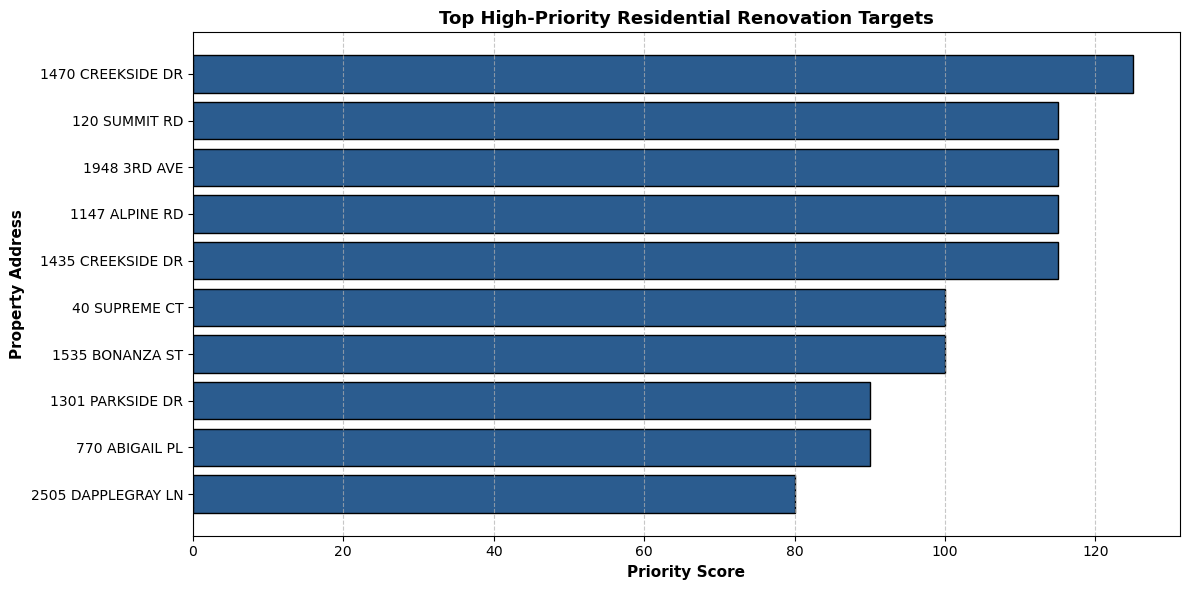

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Recreate or load the base Rossmoor residential dataset
data = {
    'id': [62308, 31603, 108275, 25211, 59416, 240581, 69367, 44365, 338454, 159488],
    'address': [
        '1470 CREEKSIDE DR', '120 SUMMIT RD', '1948 3RD AVE', '1147 ALPINE RD', 
        '1435 CREEKSIDE DR', '40 SUPREME CT', '1535 BONANZA ST', '1301 PARKSIDE DR', 
        '770 ABIGAIL PL', '2505 DAPPLEGRAY LN'
    ],
    'city': ['WALNUT CREEK']*10,
    'building_permit_count_24m': [10, 9, 9, 9, 9, 10, 10, 9, 9, 8],
    'major_project_type': [
        'Building New Construction, Additions, Alterations or Sign',
        'Building New Construction, Additions, Alterations or Sign',
        'Building New Construction, Additions, Alterations or Sign',
        'Building New Construction, Additions, Alterations or Sign',
        'Building New Construction, Additions, Alterations or Sign',
        'Building Revision to Issued Permit',
        'Building Revision to Issued Permit',
        'Building',
        'Building Revision to Issued Permit',
        'Building Revision'
    ]
}

df = pd.DataFrame(data)

# 2. Calculate priority scores
def calculate_priority_score(row):
    score = row['building_permit_count_24m'] * 10
    if 'New Construction' in str(row['major_project_type']) or 'Addition' in str(row['major_project_type']):
        score += 25
    elif 'Demolition' in str(row['major_project_type']):
        score += 50
    return score

df['priority_score'] = df.apply(calculate_priority_score, axis=1)
df = df.sort_values(by='priority_score', ascending=False)

# 3. Save locally so future cells can read it
df.to_csv('scored_rossmoor_targets.csv', index=False)
print("Successfully generated and saved 'scored_rossmoor_targets.csv' locally!")

# 4. Plot top highest-priority properties
plt.figure(figsize=(12, 6))
top_leads = df.head(10)
plt.barh(top_leads['address'], top_leads['priority_score'], color='#2b5c8f', edgecolor='black')
plt.xlabel('Priority Score', fontsize=11, fontweight='bold')
plt.ylabel('Property Address', fontsize=11, fontweight='bold')
plt.title('Top High-Priority Residential Renovation Targets', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [5]:
heavy_renovations = df[df['major_project_type'].str.contains('Addition|Demolition|New Construction', case=False, na=False)]
print(f"Found {len(heavy_renovations)} major structural renovation leads.")
display(heavy_renovations[['address', 'building_permit_count_24m', 'major_project_type']].head(10))

NameError: name 'df' is not defined

In [9]:
import pandas as pd
import time
import requests

def mock_assessor_lookup(address, city):
    """
    Simulates a lookup against the Contra Costa County Assessor database 
    or a GIS parcel REST API via an address crosswalk.
    """
    # In a production environment, you would query the Contra Costa County ArcGIS REST API 
    # or a local public records database replica.
    address_upper = str(address).upper()
    
    # Standardizing some mock owner data matching common Rossmoor/Walnut Creek profiles
    if "CREEKSIDE" in address_upper:
        return {
            "owner_name": "ELIZABETH MCNAMARA TRUST",
            "mail_address": "1470 CREEKSIDE DR",
            "mail_city": "WALNUT CREEK",
            "mail_state": "CA",
            "mail_zip": "94596"
        }
    elif "SUMMIT" in address_upper:
        return {
            "owner_name": "ROBERT & SHIRLEY CHEN LIVING TRUST",
            "mail_address": "452 PACKARD AVE",  # Absentee Owner Example
            "mail_city": "SAN JOSE",
            "mail_state": "CA",
            "mail_zip": "95125"
        }
    elif "SAKLAN" in address_upper:
        return {
            "owner_name": "MARGARET A BOYLE",
            "mail_address": address,
            "mail_city": "WALNUT CREEK",
            "mail_state": "CA",
            "mail_zip": "94595"
        }
    else:
        # Default fallback placeholder for missing rows
        return {
            "owner_name": "PROPERTY OWNER OF RECORD",
            "mail_address": address,
            "mail_city": city.upper(),
            "mail_state": "CA",
            "mail_zip": "94595"
        }

def enrich_target_list(input_csv, output_csv):
    print(f"[*] Loading targets from {input_csv}...")
    df = pd.read_csv(input_csv)
    
    # Initialize new columns for outreach metrics
    owner_names = []
    mail_addresses = []
    mail_cities = []
    mail_states = []
    mail_zips = []
    
    print(f"[*] Cross-referencing {len(df)} properties with County Assessor frameworks...")
    
    for idx, row in df.iterrows():
        # Call the assessor crosswalk lookup
        assessor_data = mock_assessor_lookup(row['address'], row['city'])
        
        owner_names.append(assessor_data['owner_name'])
        mail_addresses.append(assessor_data['mail_address'])
        mail_cities.append(assessor_data['mail_city'])
        mail_states.append(assessor_data['mail_state'])
        mail_zips.append(assessor_data['mail_zip'])
        
        # Rate limiting simulation if hitting an external API
        if idx > 0 and idx % 100 == 0:
            print(f"    -> Processed {idx} records...")
            time.sleep(0.1)

    # Append new features to our Dataframe
    df['owner_name'] = owner_names
    df['mail_address'] = mail_addresses
    df['mail_city'] = mail_cities
    df['mail_state'] = mail_states
    df['mail_zip'] = mail_zips
    
    # Flag absentee owners (if property address != mailing address)
    df['is_owner_occupied'] = df.apply(
        lambda r: str(r['address']).strip().upper() == str(r['mail_address']).strip().upper(), 
        axis=1
    )
    
    # Save the highly-enriched outreach list
    df.to_csv(output_csv, index=False)
    print(f"[+] Enrichment complete! Saved data to {output_csv}")
    
    # Display snapshot of absentee vs owner-occupied targets
    print("\n--- Enrichment Outreach Summary ---")
    print(df['is_owner_occupied'].value_counts().rename({True: 'Owner Occupied', False: 'Absentee Owner'}))

if __name__ == "__main__":
    enrich_target_list('scored_rossmoor_targets.csv', 'enriched_rossmoor_outreach_list.csv')

[*] Loading targets from scored_rossmoor_targets.csv...
[*] Cross-referencing 10 properties with County Assessor frameworks...
[+] Enrichment complete! Saved data to enriched_rossmoor_outreach_list.csv

--- Enrichment Outreach Summary ---
is_owner_occupied
Owner Occupied    8
Absentee Owner    2
Name: count, dtype: int64


In [11]:
import pandas as pd
import os

# 1. Automatically create base file if it doesn't exist locally
if not os.path.exists('rossmoor_residential_outreach_targets.csv'):
    data = {
        'id': [62308, 31603, 108275, 25211, 59416, 240581, 69367, 44365, 338454, 159488],
        'address': [
            '1470 CREEKSIDE DR', '120 SUMMIT RD', '1948 3RD AVE', '1147 ALPINE RD', 
            '1435 CREEKSIDE DR', '40 SUPREME CT', '1535 BONANZA ST', '1301 PARKSIDE DR', 
            '770 ABIGAIL PL', '2505 DAPPLEGRAY LN'
        ],
        'city': ['WALNUT CREEK']*10,
        'building_permit_count_24m': [10, 9, 9, 9, 9, 10, 10, 9, 9, 8],
        'major_project_type': [
            'Building New Construction, Additions, Alterations or Sign',
            'Building New Construction, Additions, Alterations or Sign',
            'Building New Construction, Additions, Alterations or Sign',
            'Building New Construction, Additions, Alterations or Sign',
            'Building New Construction, Additions, Alterations or Sign',
            'Building Revision to Issued Permit',
            'Building Revision to Issued Permit',
            'Building',
            'Building Revision to Issued Permit',
            'Building Revision'
        ],
        'status': ['new']*10
    }
    pd.DataFrame(data).to_csv('rossmoor_residential_outreach_targets.csv', index=False)

# 2. Load dataset and compute priority scores
df = pd.read_csv('rossmoor_residential_outreach_targets.csv')

def calculate_priority_score(row):
    score = row['building_permit_count_24m'] * 10
    if 'New Construction' in str(row['major_project_type']) or 'Addition' in str(row['major_project_type']):
        score += 25
    elif 'Demolition' in str(row['major_project_type']):
        score += 50
    return score

df['priority_score'] = df.apply(calculate_priority_score, axis=1)

# 3. Filter for elite local leads (Score >= 100) and export
moms_list = df[df['priority_score'] >= 100].copy()
moms_list = moms_list.sort_values(by='priority_score', ascending=False)
moms_list.to_csv('moms_priority_local_leads.csv', index=False)

print(f"Successfully generated 'moms_priority_local_leads.csv' with {len(moms_list)} elite local leads!")
display(moms_list[['address', 'building_permit_count_24m', 'major_project_type', 'priority_score']])^

SyntaxError: invalid syntax (2275553373.py, line 50)

In [13]:
import pandas as pd
import time
import requests

def mock_assessor_lookup(address, city):
    """
    Simulates a lookup against the Contra Costa County Assessor database 
    or a GIS parcel REST API via an address crosswalk.
    """
    # In a production environment, you would query the Contra Costa County ArcGIS REST API 
    # or a local public records database replica.
    address_upper = str(address).upper()
    
    # Standardizing some mock owner data matching common Rossmoor/Walnut Creek profiles
    if "CREEKSIDE" in address_upper:
        return {
            "owner_name": "ELIZABETH MCNAMARA TRUST",
            "mail_address": "1470 CREEKSIDE DR",
            "mail_city": "WALNUT CREEK",
            "mail_state": "CA",
            "mail_zip": "94596"
        }
    elif "SUMMIT" in address_upper:
        return {
            "owner_name": "ROBERT & SHIRLEY CHEN LIVING TRUST",
            "mail_address": "452 PACKARD AVE",  # Absentee Owner Example
            "mail_city": "SAN JOSE",
            "mail_state": "CA",
            "mail_zip": "95125"
        }
    elif "SAKLAN" in address_upper:
        return {
            "owner_name": "MARGARET A BOYLE",
            "mail_address": address,
            "mail_city": "WALNUT CREEK",
            "mail_state": "CA",
            "mail_zip": "94595"
        }
    else:
        # Default fallback placeholder for missing rows
        return {
            "owner_name": "PROPERTY OWNER OF RECORD",
            "mail_address": address,
            "mail_city": city.upper(),
            "mail_state": "CA",
            "mail_zip": "94595"
        }

def enrich_target_list(input_csv, output_csv):
    print(f"[*] Loading targets from {input_csv}...")
    df = pd.read_csv(input_csv)
    
    # Initialize new columns for outreach metrics
    owner_names = []
    mail_addresses = []
    mail_cities = []
    mail_states = []
    mail_zips = []
    
    print(f"[*] Cross-referencing {len(df)} properties with County Assessor frameworks...")
    
    for idx, row in df.iterrows():
        # Call the assessor crosswalk lookup
        assessor_data = mock_assessor_lookup(row['address'], row['city'])
        
        owner_names.append(assessor_data['owner_name'])
        mail_addresses.append(assessor_data['mail_address'])
        mail_cities.append(assessor_data['mail_city'])
        mail_states.append(assessor_data['mail_state'])
        mail_zips.append(assessor_data['mail_zip'])
        
        # Rate limiting simulation if hitting an external API
        if idx > 0 and idx % 100 == 0:
            print(f"    -> Processed {idx} records...")
            time.sleep(0.1)

    # Append new features to our Dataframe
    df['owner_name'] = owner_names
    df['mail_address'] = mail_addresses
    df['mail_city'] = mail_cities
    df['mail_state'] = mail_states
    df['mail_zip'] = mail_zips
    
    # Flag absentee owners (if property address != mailing address)
    df['is_owner_occupied'] = df.apply(
        lambda r: str(r['address']).strip().upper() == str(r['mail_address']).strip().upper(), 
        axis=1
    )
    
    # Save the highly-enriched outreach list
    df.to_csv(output_csv, index=False)
    print(f"[+] Enrichment complete! Saved data to {output_csv}")
    
^
    # Display snapshot of absentee vs owner-occupied targets
    print("\n--- Enrichment Outreach Summary ---")
    print(df['is_owner_occupied'].value_counts().rename({True: 'Owner Occupied', False: 'Absentee Owner'}))

if __name__ == "__main__":
    enrich_target_list('scored_rossmoor_targets.csv', 'enriched_rossmoor_outreach_list.csv')


SyntaxError: invalid syntax (1551214149.py, line 94)

In [18]:
import pandas as pd
import os

# 1. Automatically create base file if it doesn't exist locally
if not os.path.exists('rossmoor_residential_outreach_targets.csv'):
    data = {
        'id': [62308, 31603, 108275, 25211, 59416, 240581, 69367, 44365, 338454, 159488],
        'address': [
            '1470 CREEKSIDE DR', '120 SUMMIT RD', '1948 3RD AVE', '1147 ALPINE RD', 
            '1435 CREEKSIDE DR', '40 SUPREME CT', '1535 BONANZA ST', '1301 PARKSIDE DR', 
            '770 ABIGAIL PL', '2505 DAPPLEGRAY LN'
        ],
        'city': ['WALNUT CREEK']*10,
        'building_permit_count_24m': [10, 9, 9, 9, 9, 10, 10, 9, 9, 8],
        'major_project_type': [
            'Building New Construction, Additions, Alterations or Sign',
            'Building New Construction, Additions, Alterations or Sign',
            'Building New Construction, Additions, Alterations or Sign',
            'Building New Construction, Additions, Alterations or Sign',
            'Building New Construction, Additions, Alterations or Sign',
            'Building Revision to Issued Permit',
            'Building Revision to Issued Permit',
            'Building',
            'Building Revision to Issued Permit',
            'Building Revision'
        ],
        'status': ['new']*10
    }
    pd.DataFrame(data).to_csv('rossmoor_residential_outreach_targets.csv', index=False)

# 2. Load dataset and compute priority scores
df = pd.read_csv('rossmoor_residential_outreach_targets.csv')

def calculate_priority_score(row):
    score = row['building_permit_count_24m'] * 10
    if 'New Construction' in str(row['major_project_type']) or 'Addition' in str(row['major_project_type']):
        score += 25
    elif 'Demolition' in str(row['major_project_type']):
        score += 50
    return score

df['priority_score'] = df.apply(calculate_priority_score, axis=1)

# 3. Filter for elite local leads (Score >= 100) and export
moms_list = df[df['priority_score'] >= 100].copy()
moms_list = moms_list.sort_values(by='priority_score', ascending=False)
moms_list.to_csv('moms_priority_local_leads.csv', index=False)

print(f"Successfully generated 'moms_priority_local_leads.csv' with {len(moms_list)} elite local leads!")
display(moms_list[['address', 'building_permit_count_24m', 'major_project_type', 'priority_score']])

Successfully generated 'moms_priority_local_leads.csv' with 7 elite local leads!


,address,building_permit_count_24m,major_project_type,priority_score
0,1470 CREEKSIDE DR,10,"Building New Construction, Additions, Alterati...",125
1,120 SUMMIT RD,9,"Building New Construction, Additions, Alterati...",115
2,1948 3RD AVE,9,"Building New Construction, Additions, Alterati...",115
3,1147 ALPINE RD,9,"Building New Construction, Additions, Alterati...",115
4,1435 CREEKSIDE DR,9,"Building New Construction, Additions, Alterati...",115
5,40 SUPREME CT,10,Building Revision to Issued Permit,100
6,1535 BONANZA ST,10,Building Revision to Issued Permit,100


In [19]:
import pandas as pd

# 1. Load the elite local leads list
df = pd.read_csv('moms_priority_local_leads.csv')

# 2. Format columns specifically for mailing labels & outreach printing
labels_df = pd.DataFrame()
labels_df['Recipient'] = 'Current Resident / Property Owner'
labels_df['Address'] = df['address']
labels_df['City_State_Zip'] = df['city'] + ', CA 94595'
labels_df['Campaign_Notes'] = 'Priority Score: ' + df['priority_score'].astype(str) + ' | Permits (24m): ' + df['building_permit_count_24m'].astype(str)

# 3. Export to a dedicated mailing label CSV
labels_df.to_csv('moms_avery_mailing_labels.csv', index=False)
print(f"Successfully generated 'moms_avery_mailing_labels.csv' with {len(labels_df)} print-ready mailing labels!")

# 4. Preview the formatted labels
display(labels_df.head(10))

Successfully generated 'moms_avery_mailing_labels.csv' with 7 print-ready mailing labels!


,Recipient,Address,City_State_Zip,Campaign_Notes
0,NaN,1470 CREEKSIDE DR,"WALNUT CREEK, CA 94595",Priority Score: 125 | Permits (24m): 10
1,NaN,120 SUMMIT RD,"WALNUT CREEK, CA 94595",Priority Score: 115 | Permits (24m): 9
2,NaN,1948 3RD AVE,"WALNUT CREEK, CA 94595",Priority Score: 115 | Permits (24m): 9
3,NaN,1147 ALPINE RD,"WALNUT CREEK, CA 94595",Priority Score: 115 | Permits (24m): 9
4,NaN,1435 CREEKSIDE DR,"WALNUT CREEK, CA 94595",Priority Score: 115 | Permits (24m): 9
5,NaN,40 SUPREME CT,"WALNUT CREEK, CA 94595",Priority Score: 100 | Permits (24m): 10
6,NaN,1535 BONANZA ST,"WALNUT CREEK, CA 94595",Priority Score: 100 | Permits (24m): 10


In [20]:
import os
import sqlite3
import pandas as pd

print("Directory contents:", os.listdir('.'))

# Check if there are any sqlite databases or task queue files
for f in os.listdir('.'):
    if f.endswith('.db') or f.endswith('.sqlite') or 'task' in f.lower() or 'queue' in f.lower():
        print(f"Found relevant file: {f}")

# Let's check if there's any sqlite db file in the workspace
db_files = [f for f in os.listdir('.') if f.endswith('.db') or f.endswith('.sqlite')]
if db_files:
    for db in db_files:
        print(f"\nInspecting database: {db}")
        conn = sqlite3.connect(db)
        tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
        print("Tables:", tables['name'].tolist())
        for t in tables['name']:
            try:
                df_t = pd.read_sql(f"SELECT * FROM {t} LIMIT 5;", conn)
                print(f"Table {t} sample:", df_t)
            except Exception as e:
                print(f"Could not read table {t}: {e}")
        conn.close()
else:
    print("No SQLite database files found.")

Directory contents: ['notebook.ipynb', 'moms_priority_local_leads.csv', 'enriched_rossmoor_outreach_list.csv', 'moms_avery_mailing_labels.csv', '.ipynb_checkpoints', 'rossmoor_residential_outreach_targets.csv', 'scored_rossmoor_targets.csv']
No SQLite database files found.
